In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
total_passageiros = df.shape[0]
print(total_passageiros)

891


In [4]:
resultado = df.groupby('Survived').size().reset_index(name='total')

print(resultado)

   Survived  total
0         0    549
1         1    342


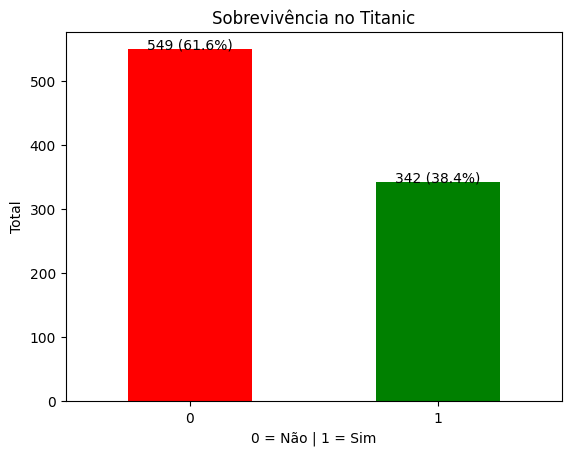

In [5]:
resultado = df['Survived'].value_counts().sort_index()

ax = resultado.plot(kind='bar', color=['red', 'green'])

total = resultado.sum()

for i, v in enumerate(resultado):
    porcentagem = (v / total) * 100
    ax.text(i, v, f'{v} ({porcentagem:.1f}%)', ha='center')

plt.title('Sobrevivência no Titanic')
plt.xlabel('0 = Não | 1 = Sim')
plt.ylabel('Total')

plt.xticks(rotation=0)

plt.show()

In [6]:
# Agrupamento e contagem
resultado = df.groupby('Survived').size().reset_index(name='total')

# Cálculo da porcentagem
resultado['porcentagem'] = round(
    resultado['total'] * 100.0 / resultado['total'].sum(), 2
)

print(resultado)




   Survived  total  porcentagem
0         0    549        61.62
1         1    342        38.38


In [7]:
sex_counts = df['Sex'].value_counts()
sex_counts

,count
Sex,
male,577
female,314


In [8]:
embarked_counts = df['Embarked'].value_counts(dropna=False)
print(embarked_counts)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


In [9]:
survival_by_gender = df.groupby(['Sex', 'Survived']).size().unstack()
print(survival_by_gender)

Survived    0    1
Sex               
female     81  233
male      468  109


In [10]:
class_counts = df['Pclass'].value_counts().sort_index()
print(class_counts)

Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [11]:
survival_by_class = df.groupby(['Pclass', 'Survived']).size().unstack()
print(survival_by_class)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


In [15]:
survival_rate_class =round(df.groupby('Pclass')['Survived'].mean() * 100)
print(survival_rate_class)

Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64


In [23]:
mean_age = df['Age'].mean()
max_age = df['Age'].max()
min_age = df['Age'].min()

print('Mean age:', round(mean_age), 'Max age:', round(max_age), 'Min age:', min_age)

Mean age: 30 Max age: 80 Min age: 0.42
